# EquiAlgo V2 — SOTA Overfitters

## What changed

The participant reports **94.63% accuracy / 94.40% macro F1** for V1 on HxBuddy. That is the only measured independent-reference result currently recorded. The entire prior method is preserved in `archive/v1_score_repair_9463/`. V2 changes the inference problem: model plausible merit criteria instead of simply clipping the committee's coefficients and enforcing demographic parity.

**V2 is experimental and unscored.** Its model-implied agreement is not an accuracy estimate validated against private labels. The requested 98% has not been established. We use aggregate evaluation feedback in model development and disclose this; the evaluated cohort is no longer an untouched validation set.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd
from IPython.display import display, Image
from data_contract import load_data, groups, verify_predictions
root=Path.cwd(); art=root/'artifacts'
history,evaluation=load_data()
summary=json.loads((art/'audit_summary.json').read_text())
display(pd.Series({'historical_rows':len(history),'evaluation_rows':len(evaluation),'scenario_count':summary['scenario_count'],'changed_from_v1':summary['changed_from_v1']}))
display(pd.DataFrame(summary['candidates']).T)
assert set(history.id_candidat).isdisjoint(evaluation.id_candidat)

historical_rows    10000
evaluation_rows     4000
scenario_count      2048
changed_from_v1      194
dtype: int64

,rows,grants,grant_rate,selection_rate_centre,selection_rate_remote,demographic_parity_gap,reference_accuracy,reference_equal_opportunity_gap,status,changed_from_v1,method,official_accuracy,v1_user_reported_accuracy
structured_merit,4000,1600,0.4,0.408938,0.386978,0.02196,None,None,"Format, IDs and budget valid; hidden-reference...",194,structured_merit,None,0.9463
broad_merit,4000,1600,0.4,0.403457,0.394963,0.008494,None,None,"Format, IDs and budget valid; hidden-reference...",152,broad_merit,None,0.9463
academic_anchor,4000,1600,0.4,0.42285,0.366708,0.056142,None,None,"Format, IDs and budget valid; hidden-reference...",170,NaN,None,NaN


## 1. Original diagnosis remains valid

The supplied random forest reproduces biased decisions: 88.13% historical agreement and a held-out regional selection gap of 18.76 points. Removing region leaves 18.05 points; removing postal prefix too leaves 17.31. Postal prefix perfectly identifies the regional block in the supplied data, while distance gives ROC AUC 0.997. These results and the unchanged executed starter are preserved in the V1 archive.

Region, distance, wealth and work can carry regional information, but correlation alone does not identify which contributions belong to merit and which to committee bias. Confusing the two was the weakness of simple coefficient deletion.

,feature,remote_prediction_auc,remote_prediction_accuracy
0,code_postal_3,1.000000,1.000000
1,all_without_region,0.999892,0.993667
2,distance_domicile_campus_km,0.997337,0.987333
3,heures_travail_semaine,0.806320,0.746000
4,revenu_familial_estime,0.697728,0.664000
5,premiere_generation_universitaire,0.587341,0.616000
6,cote_r_equivalent,0.552321,0.588333
7,programme_etudes,0.547622,0.591667


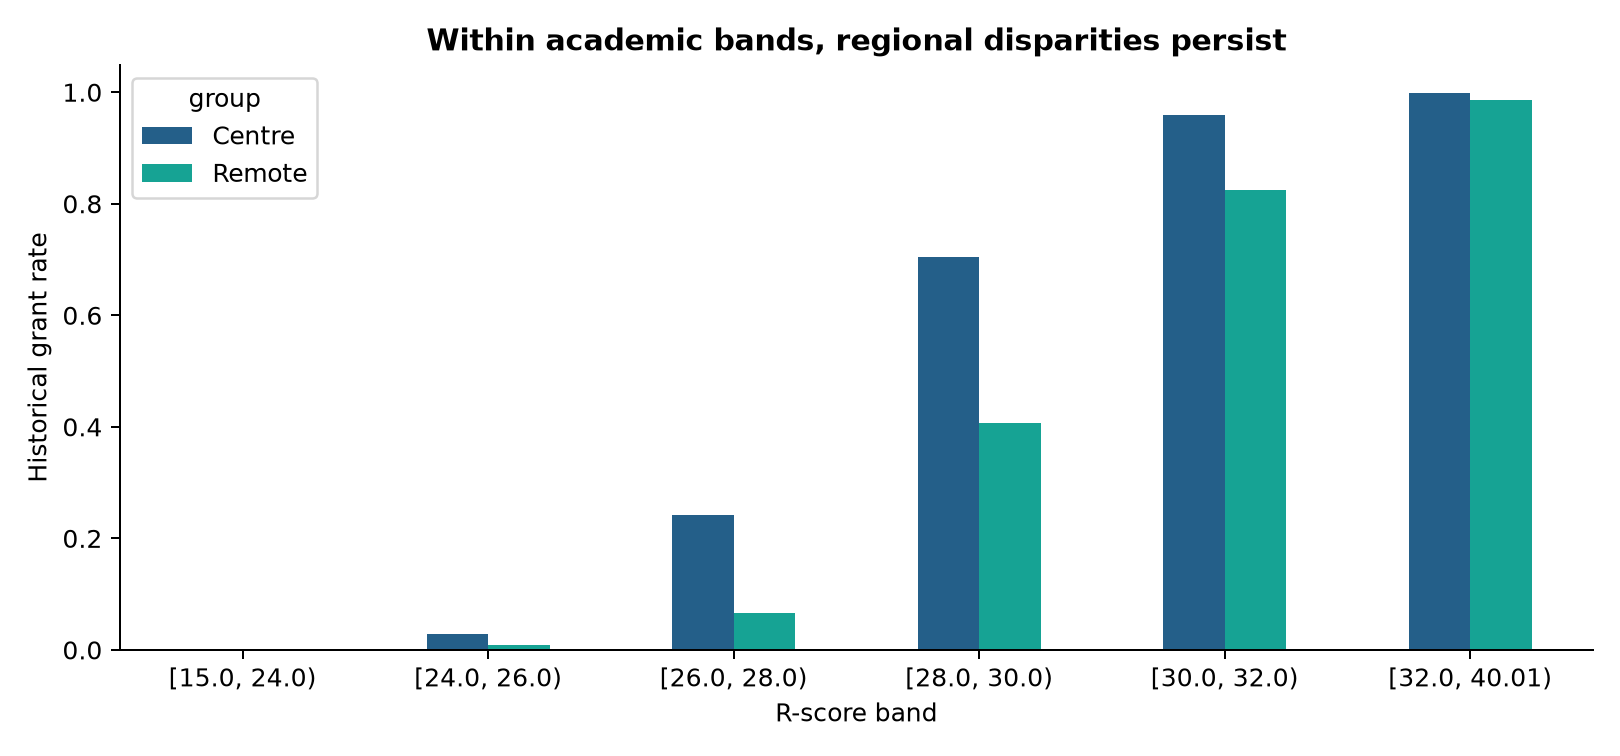

,fold,historical_log_loss,historical_agreement
income_link,,,
log,2.0,0.258989,0.8872
raw,2.0,0.260921,0.8864


In [2]:
v1=root/'archive'/'v1_score_repair_9463'/'artifacts'
display(pd.read_csv(v1/'proxy_audit.csv'))
display(Image(filename=str(v1/'academic_bands.png')))
display(pd.read_csv(art/'historical_cross_validation.csv').groupby('income_link').mean(numeric_only=True))

## 2. Structural investigation, including rejected ideas

We tested linear versus nonlinear income effects, additive splines, work saturation, interactions and logistic/probit noise. A pooled logistic model with log income improves historical log loss, but nonlinear decompositions do **not** reliably identify a legitimate financial-need benefit. We therefore do not claim the historical data recovered the reference's need coefficient.

The logged five-fold historical cross-validation compares raw and log income on the same folds (seed 87). Only training rows fit each diagnostic. These metrics validate a model of committee behavior, not a model of independent merit. The full-fit work association provides a scale for a broad prior, not a fixed entitlement to work credit.

## 3. New method: inverse merit hypotheses

Each hypothesis defines a latent score from R score, paid work, log household income, first-generation status and commute burden. R-score coefficient is 1. Work ranges from 0 to 1.4 times the learned academic-normalized committee coefficient (bounded at .25 R points/hour). Log-income coefficient ranges from -.8 to 0, first-generation benefit from 0 to .6 R points, and commute benefit from 0 to .16 points per 100 km. These directions and ranges are explicit normative priors.

We draw 2,048 Sobol hypotheses, seed 20261003. Each also assumes Gaussian merit noise of .04–.65 R-score units and an intercept giving 40% expected eligibility in this cohort. We weight hypotheses by compatibility with V1's reported accuracy. The brief's .270 baseline opportunity gap contributes a **weak** compatibility term (width .04) because its exact cohort/model provenance is unknown. Macro F1 is recorded but is not treated as an independent likelihood observation of the same predictions.

The primary `structured_merit` candidate restricts noise to at most .30 R-score units, testing whether missing criteria explain most of V1's errors. This is an ambitious assumption, not a learned fact. `broad_merit` allows the full noise range. `academic_anchor` is a falsification alternative retaining only one quarter of the committee's work coefficient alongside R score.

The final primary ranking averages eligibility probabilities across compatible hypotheses and takes the top 1,600. There is no direct region, postal or program score term, and no forced regional selection parity. Commute burden still carries regional information. Zero direct regional coefficients do not prove counterfactual or causal fairness.

method                                                         structured_merit
scenario_count                                                             2048
seed                                                                   20261003
committee                     {'income_link': 'log', 'features': ['intercept...
effective_scenarios                                                  121.012491
weighted_mean_coefficients    [0.9999999999999989, 0.030086679567379225, -0....
weighted_noise_r_units                                                 0.189306
feedback                      {'accuracy': 0.9463, 'macro_f1': 0.944, 'sourc...
accuracy_for_this_model                                                    None
warning                       Aggregate evaluation feedback used. Model-impl...
dtype: object

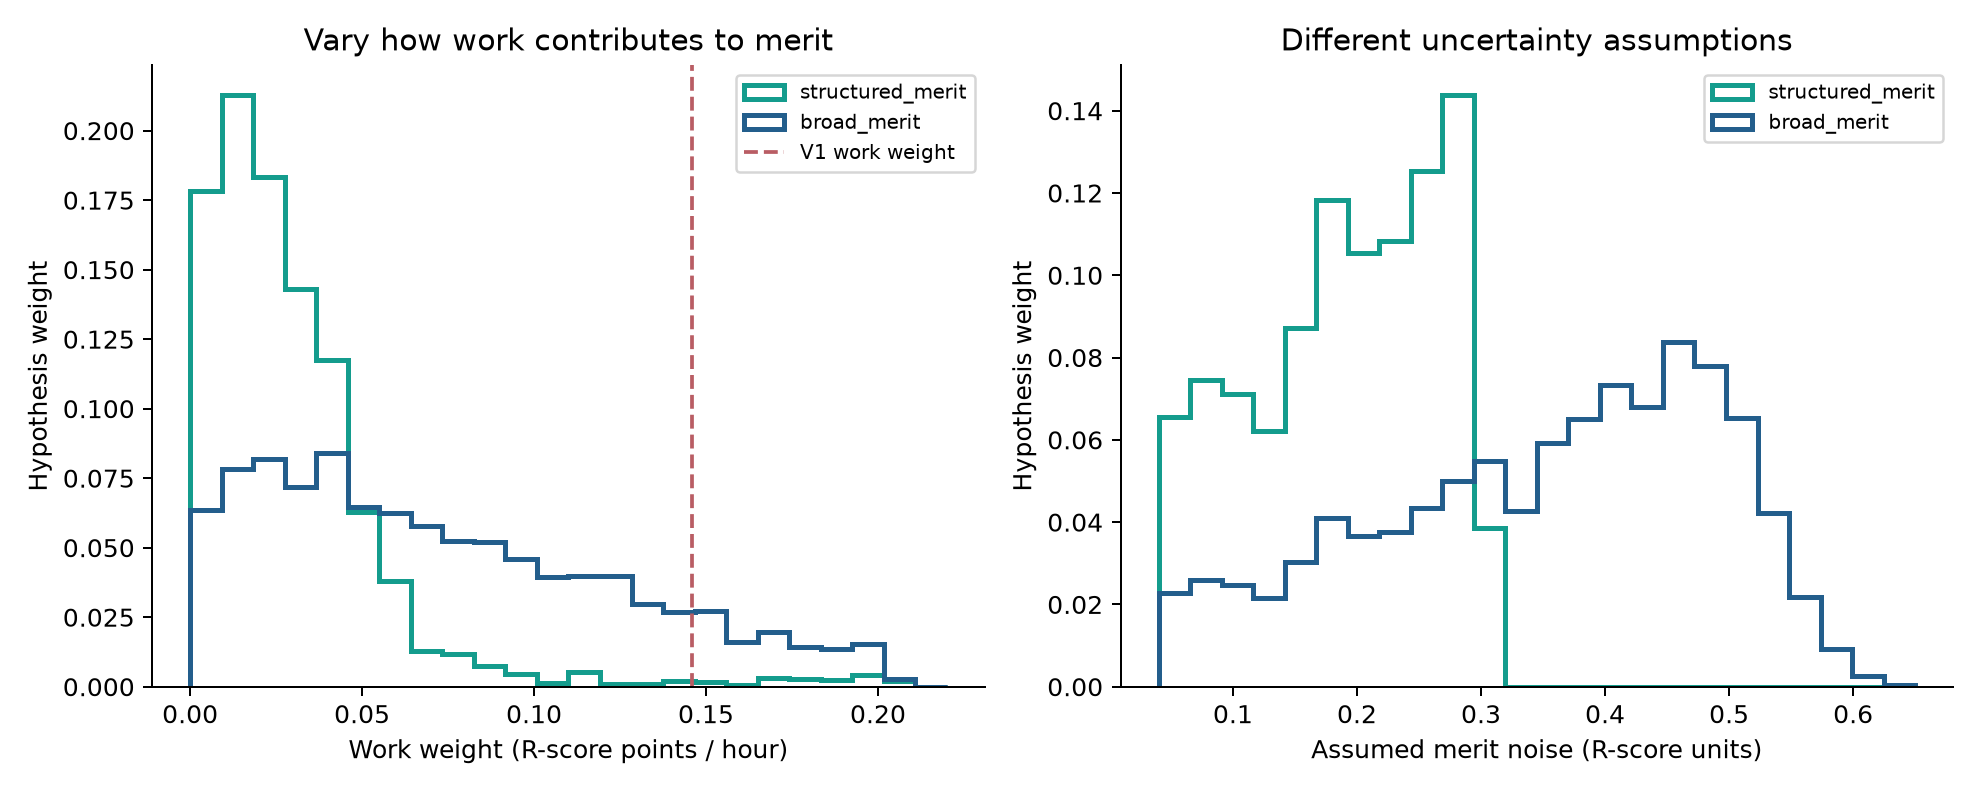

,group,count,mean_r,mean_work_hours,mean_income,first_generation_rate,remote_rate
0,new_grantees,97,28.723196,7.226804,58273.020619,0.57732,0.319588
1,no_longer_selected,97,28.155773,15.319588,79264.701031,0.28866,0.536082


In [3]:
display(pd.Series(json.loads((art/'model_parameters.json').read_text())))
display(Image(filename=str(art/'hypothesis_weights.png')))
display(pd.read_csv(art/'decision_change_summary.csv'))

## 4. Fairness objective and Pareto sweep

Our target is equal opportunity among independently eligible applicants, with a fixed budget. Those eligibility labels are unavailable. The sweep therefore uses **model-implied** opportunity: sum of selected eligibility weights / sum of all eligibility weights within each regional block. We enumerate feasible grant counts and maximize summed eligibility weight under ten opportunity tolerances, always selecting 1,600.

The plot is a sensitivity frontier under stated hypotheses, **not a verified hidden-reference Pareto frontier**. Its vertical values are expected agreement under the same assumed model; they cannot be presented as validation accuracy. Demographic parity is reported descriptively. The primary default is unconstrained ranking; the alternative constraints show the cost and instability of acting as if the inferred labels were known.

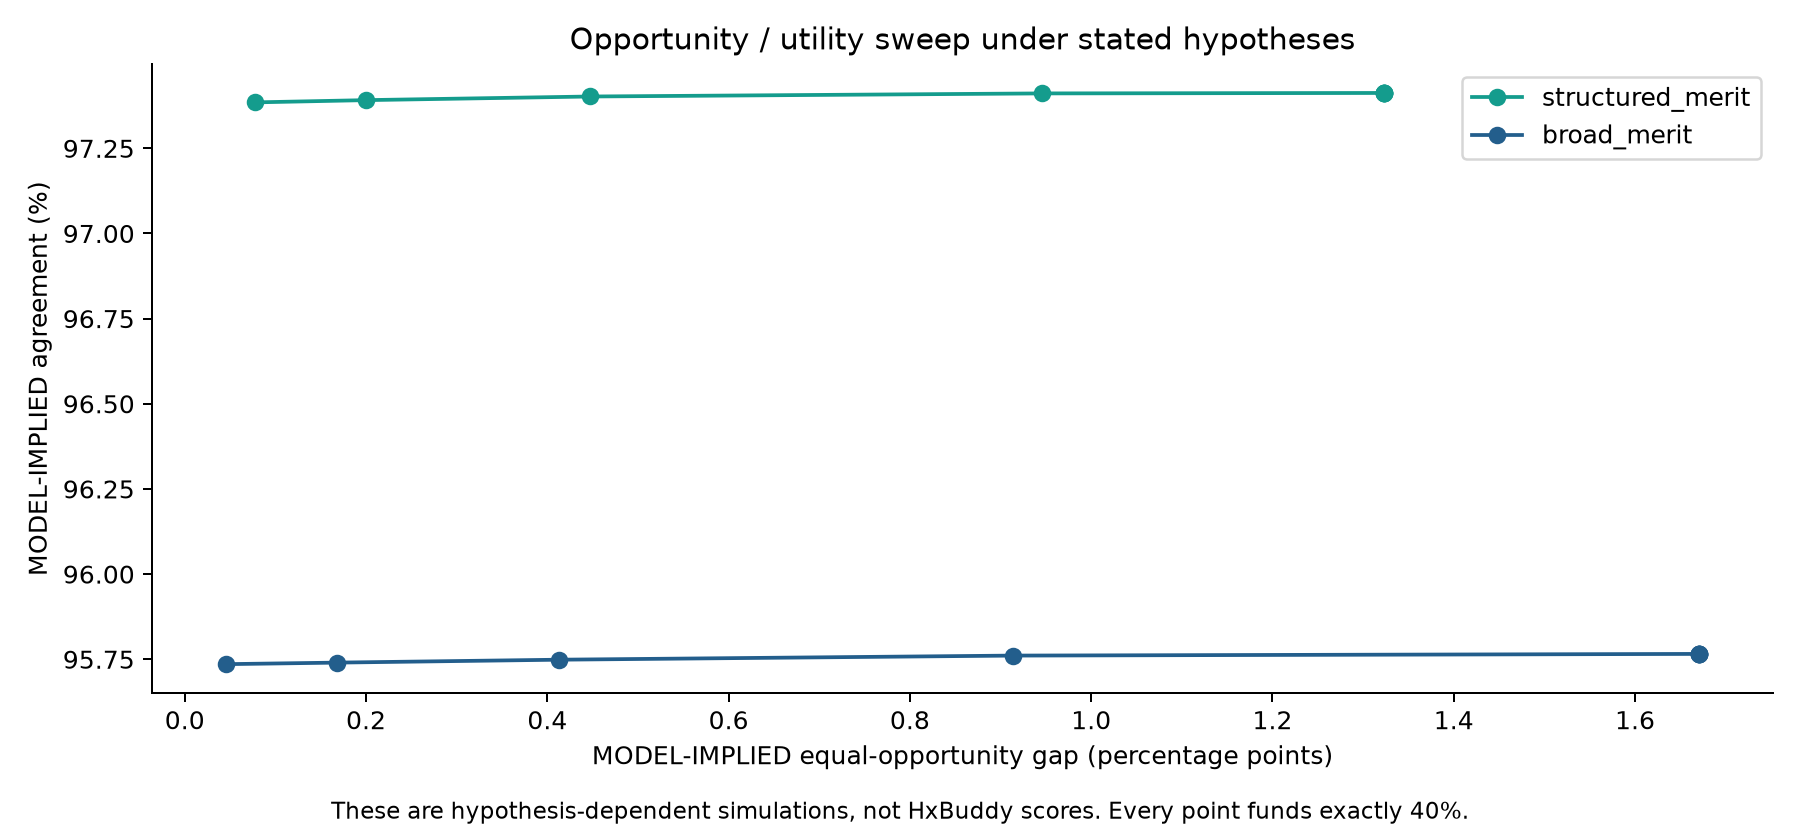

,model,eop_tolerance,model_implied_agreement,model_implied_eop_gap,measured_dp_gap,changed_from_v1
0,structured_merit,1.000,0.974125,0.013228,0.021960,194
1,structured_merit,0.100,0.974125,0.013228,0.021960,194
2,structured_merit,0.075,0.974125,0.013228,0.021960,194
3,structured_merit,0.050,0.974125,0.013228,0.021960,194
4,structured_merit,0.030,0.974125,0.013228,0.021960,194
5,structured_merit,0.020,0.974125,0.013228,0.021960,194
6,structured_merit,0.010,0.974112,0.009455,0.018852,196
7,structured_merit,0.005,0.974021,0.004475,0.014709,198
8,structured_merit,0.002,0.973914,0.002000,0.012637,196
9,structured_merit,0.001,0.973848,0.000770,0.011601,194


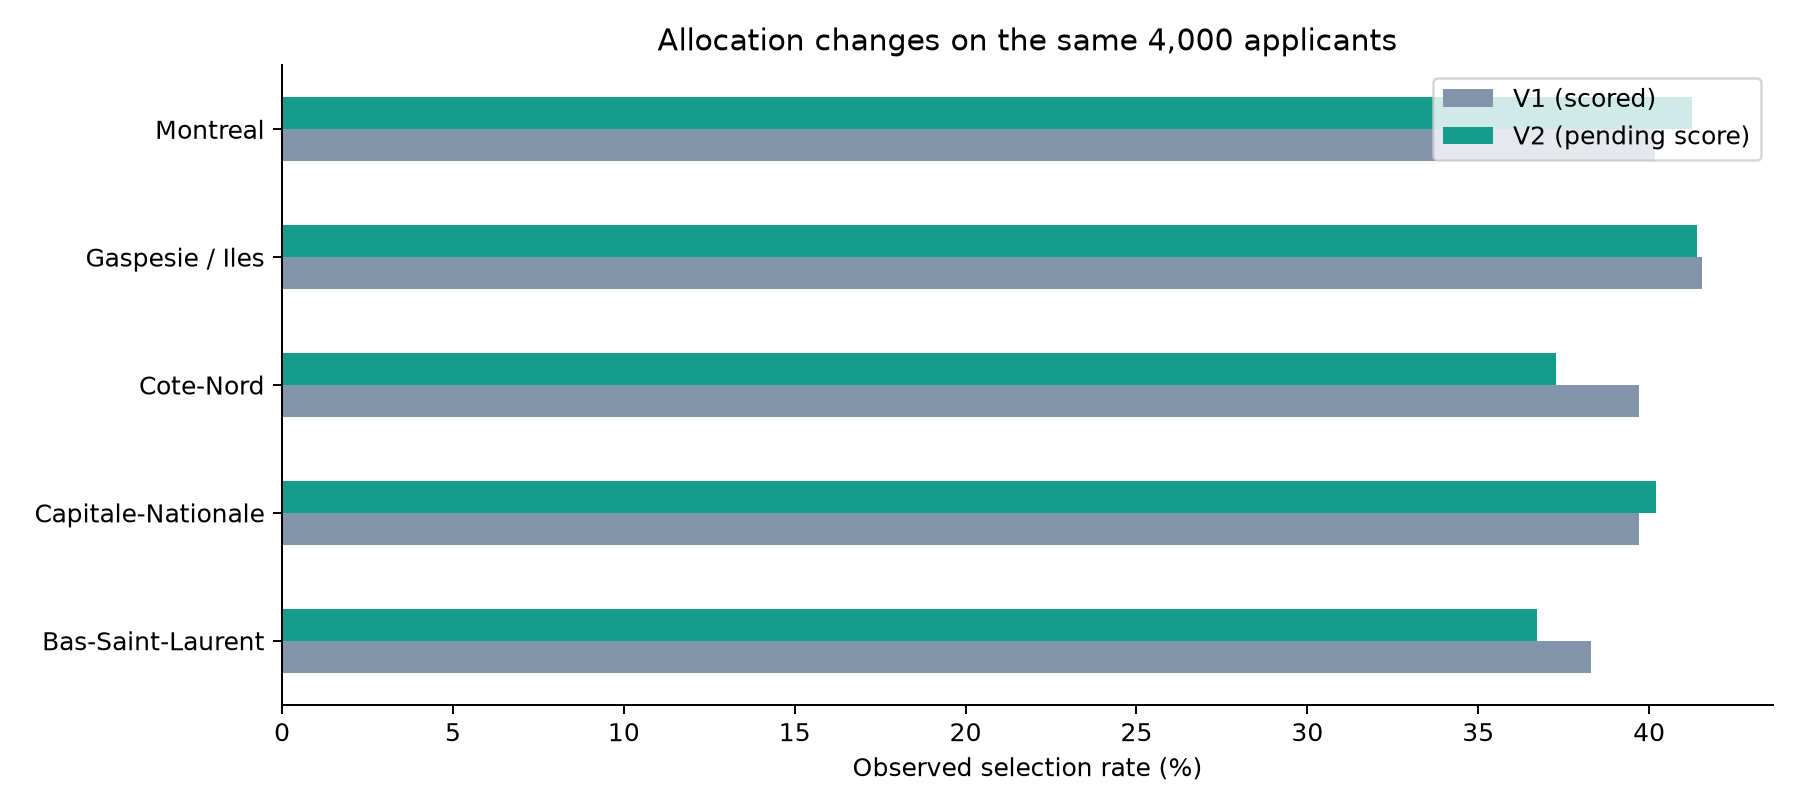

,region_administrative,premiere_generation_universitaire,programme_etudes,size,mean,small_cell
0,Bas-Saint-Laurent,0,Arts et lettres,54,0.351852,False
1,Bas-Saint-Laurent,0,Genie,60,0.366667,False
2,Bas-Saint-Laurent,0,Sante,47,0.276596,False
3,Bas-Saint-Laurent,0,Sciences,64,0.359375,False
4,Bas-Saint-Laurent,0,Sciences sociales,49,0.265306,False
5,Bas-Saint-Laurent,1,Arts et lettres,58,0.327586,False
6,Bas-Saint-Laurent,1,Genie,40,0.450000,False
7,Bas-Saint-Laurent,1,Sante,34,0.470588,False
8,Bas-Saint-Laurent,1,Sciences,43,0.488372,False
9,Bas-Saint-Laurent,1,Sciences sociales,55,0.381818,False


In [4]:
display(Image(filename=str(art/'pareto_front.png')))
display(pd.read_csv(art/'pareto.csv'))
display(Image(filename=str(art/'regional_access.png')))
display(pd.read_csv(art/'intersection_audit.csv'))

## 5. Uncertainty, failure modes and governance

The inverse problem is not identifiable from one aggregate score. Many distinct merit rules fit it. The low-noise prior may be wrong; monetary-need, first-generation and commute benefits are not identified by the biased labels. Gaussian noise, additive scoring and a 40% latent-eligibility rate can all be misspecified. Finite Sobol scenarios approximate the prior; repeat with a larger set to assess numerical sensitivity. Aggregate-feedback tuning risks leaderboard overfitting and does not certify out-of-sample generalization.

Use the archived V1 as a scored fallback. Record every evaluated CSV by hash. Do not call a candidate better until its official result arrives. A representative independent review sample, including rejected cases, is required before production. Paid-work credit can disadvantage students unable to work; need estimates and first-generation indicators need consent, data quality review and human appeals. See `MONITORING.md` for owners, controls and escalation.

Regional and intersectional rates include counts; flag cells under 30 and use larger review samples rather than declaring small-cell gaps conclusive. Expected-opportunity constraints on assumed labels must never be treated as production safety guarantees.

In [5]:
submission=pd.read_csv(root/'predictions.csv')
display(pd.Series(verify_predictions(evaluation,submission)))
assert submission.decision_octroi.sum()==1600
display(pd.read_csv(root/'predictions_history'/'comparison.csv')[['model','official_accuracy','official_macro_f1','changed_decisions_from_previous']])
print('V2 official accuracy: not yet measured. V1 score must not be transferred to V2.')

rows                                                                            4000
grants                                                                          1600
grant_rate                                                                       0.4
selection_rate_centre                                                       0.408938
selection_rate_remote                                                       0.386978
demographic_parity_gap                                                       0.02196
reference_accuracy                                                              None
reference_equal_opportunity_gap                                                 None
status                             Format, IDs and budget valid; hidden-reference...
dtype: object

,model,official_accuracy,official_macro_f1,changed_decisions_from_previous
0,baseline-original,NaN,NaN,NaN
1,corrected-initial,NaN,NaN,388.0
2,corrected-policy-audited,0.9463,0.944,0.0
3,v2-structured_merit,NaN,NaN,194.0
4,v2-broad_merit,NaN,NaN,60.0
5,v2-academic-anchor,NaN,NaN,126.0


V2 official accuracy: not yet measured. V1 score must not be transferred to V2.


## Sources and tools

Supplied IVADO briefs, README, baseline notebook and data; [HxBuddy](https://hxbuddy.ca/); participant-reported SOTA Overfitters score; [SciPy Sobol documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.qmc.Sobol.html); [SciPy normal CDF](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.ndtr.html); [Fairlearn metrics](https://fairlearn.org/main/user_guide/assessment/common_fairness_metrics.html).

Python, NumPy, pandas, SciPy, scikit-learn, Matplotlib, Jupyter and ReportLab. OpenAI Codex assisted with analysis, code and writing. No external training dataset, hidden answer key, pretrained predictor or candidate-ID predictive feature was used.

Reproduce: `python model_corrige.py`, `python build_audit.py`, `python build_presentation.py`, `python -m unittest discover -s tests`. Every CSV remains versioned. To rerun V1, use its archived files with the original participant data path.